# Contact Angle Extractor

폴더 안의 분석 이미지(`시간.png`)에서 분홍색 `CA` 값을 읽어 Excel 파일로 저장합니다. `mode1`은 CA만, `mode2`는 CA, CA(L), CA(R)를 저장합니다.


In [17]:
# 1. 분석할 폴더와 모드를 설정하세요.
FOLDER_PATH = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\5. Wettability 탐구\1. 실험자료\260907_PDMS 다양한 코팅\6. Al-OR-HDFS (4)"

# "mode1": CA만 저장 / "mode2": CA, CA(L), CA(R) 저장
MODE = "mode2"

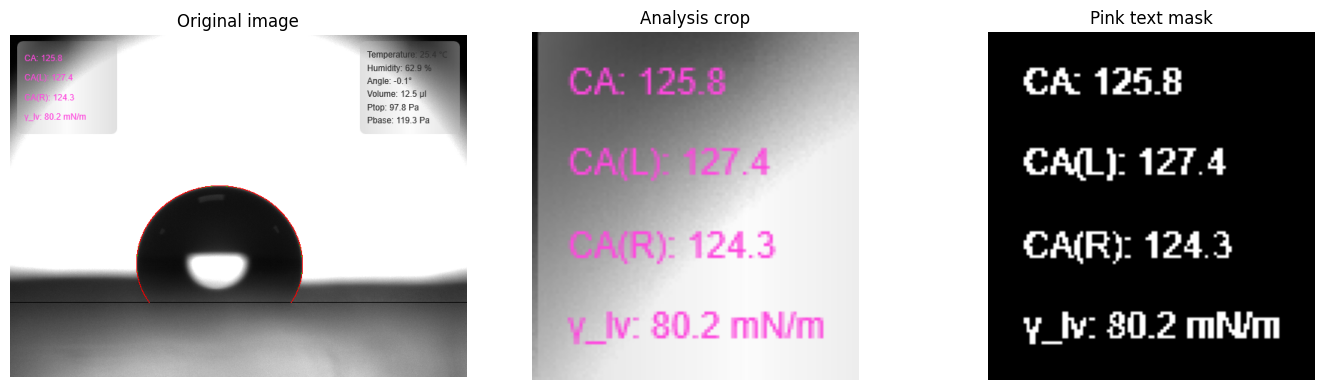

Saved: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\5. Wettability 탐구\1. 실험자료\260907_PDMS 다양한 코팅\6. Al-OR-HDFS (4)\contact_angle_mode2.xlsx


,File name,CA,CA_L,CA_R
0,00.37.04.png,125.800000,127.400000,124.30000
1,00.37.55.png,125.700000,126.800000,124.60000
2,00.46.00.png,122.200000,122.200000,122.20000
3,Mean,124.566667,125.466667,123.70000
4,Standard deviation,2.050203,2.844878,1.30767


In [18]:
# Tesseract가 PATH에 없다면 실행 파일 경로를 입력하세요. 보통은 아래 기본값을 그대로 사용하면 됩니다.
TESSERACT_CMD = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# None이면 선택한 폴더에 contact_angle_mode1.xlsx 또는 contact_angle_mode2.xlsx로 저장됩니다.
OUTPUT_PATH = None

# 2. 아래 셀을 실행하면 미리보기 후 Excel 파일을 생성합니다.

# Analysis functions are kept in this notebook so no separate Python file is needed.
import importlib.util
import re
import zipfile
from dataclasses import dataclass
import pathlib
Path = pathlib.Path
from xml.sax.saxutils import escape

import cv2
import numpy as np
import pandas as pd


IMAGE_SUFFIX = ".png"
ORIGINAL_SUFFIX = "_original"


@dataclass
class OCRAttempt:
    text: str
    values: dict[str, float | None]
    score: int


def _has_package(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None


def _normalise_mode(mode: str) -> str:
    normalised = mode.strip().lower().replace(" ", "").replace("-", "")
    aliases = {
        "1": "mode1",
        "mode1": "mode1",
        "ca": "mode1",
        "caonly": "mode1",
        "2": "mode2",
        "mode2": "mode2",
        "calcar": "mode2",
        "full": "mode2",
    }
    if normalised not in aliases:
        raise ValueError("mode must be one of: 'mode1', 'mode2', 'ca', 'full'.")
    return aliases[normalised]


def _extract_base_name(file_path: Path) -> str:
    stem = file_path.stem
    if stem.endswith(ORIGINAL_SUFFIX):
        return stem[: -len(ORIGINAL_SUFFIX)]
    return stem


def _sort_key_from_name(name: str) -> tuple[int, ...] | str:
    if re.fullmatch(r"\d{1,2}\.\d{1,2}\.\d{1,2}", name):
        return tuple(int(part) for part in name.split("."))
    return name


def list_analysis_images(folder_path: str | Path) -> list[Path]:
    folder = Path(folder_path)
    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    images = [
        path
        for path in folder.glob(f"*{IMAGE_SUFFIX}")
        if path.is_file() and not path.stem.endswith(ORIGINAL_SUFFIX)
    ]
    return sorted(images, key=lambda path: _sort_key_from_name(_extract_base_name(path)))


def load_image(image_path: str | Path) -> np.ndarray:
    file_bytes = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    return image


def crop_analysis_region(image: np.ndarray, width_ratio: float = 0.35, height_ratio: float = 0.35) -> np.ndarray:
    height, width = image.shape[:2]
    x2 = max(1, int(width * width_ratio))
    y2 = max(1, int(height * height_ratio))
    return image[:y2, :x2].copy()


def build_pink_text_mask(region: np.ndarray) -> np.ndarray:
    """Keep the magenta annotation pixels without thickening their letter shapes."""
    hsv = cv2.cvtColor(region, cv2.COLOR_BGR2HSV)
    lower_pink = np.array([135, 60, 100], dtype=np.uint8)
    upper_pink = np.array([179, 255, 255], dtype=np.uint8)
    return cv2.inRange(hsv, lower_pink, upper_pink)
def tighten_to_text(mask_image: np.ndarray, source_region: np.ndarray, padding: int = 12) -> tuple[np.ndarray, np.ndarray]:
    points = cv2.findNonZero(mask_image)
    if points is None:
        return source_region, mask_image

    x, y, width, height = cv2.boundingRect(points)
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(source_region.shape[1], x + width + padding)
    y2 = min(source_region.shape[0], y + height + padding)
    return source_region[y1:y2, x1:x2].copy(), mask_image[y1:y2, x1:x2].copy()


def prepare_ocr_candidates(image_path: str | Path) -> list[np.ndarray]:
    """Return one high-resolution OCR image for each pink annotation line."""
    image = load_image(image_path)
    region = crop_analysis_region(image)
    mask = build_pink_text_mask(region)

    active_rows = np.count_nonzero(mask, axis=1) > 1
    line_ranges: list[tuple[int, int]] = []
    start = None
    for y, is_active in enumerate(active_rows):
        if is_active and start is None:
            start = y
        if start is not None and (not is_active or y == len(active_rows) - 1):
            end = y if not is_active else y + 1
            if end - start >= 2:
                line_ranges.append((start, end))
            start = None

    line_images = []
    for y1, y2 in line_ranges:
        line_mask = mask[y1:y2]
        active_columns = np.where(np.count_nonzero(line_mask, axis=0) > 0)[0]
        if active_columns.size == 0:
            continue

        padding = 4
        x1 = max(0, int(active_columns.min()) - padding)
        x2 = min(region.shape[1], int(active_columns.max()) + padding + 1)
        crop_y1 = max(0, y1 - padding)
        crop_y2 = min(region.shape[0], y2 + padding)
        line_crop = region[crop_y1:crop_y2, x1:x2]

        # Upscale original colour pixels first, then isolate pink text for sharper digits.
        enlarged = cv2.resize(line_crop, None, fx=8, fy=8, interpolation=cv2.INTER_LANCZOS4)
        hsv = cv2.cvtColor(enlarged, cv2.COLOR_BGR2HSV)
        pink_text = cv2.inRange(hsv, (135, 50, 50), (179, 255, 255))
        line_images.append(cv2.bitwise_not(pink_text))

    if not line_images:
        raise ValueError(f"No pink analysis text was found in: {image_path}")
    return line_images


def _run_tesseract_ocr(
    image: np.ndarray,
    tesseract_cmd: str | None = None,
    page_segmentation: int = 6,
) -> str:
    if not _has_package("pytesseract"):
        raise ImportError(
            "pytesseract is not installed. Run 'pip install pytesseract' and install the Tesseract OCR app."
        )

    import pytesseract

    if tesseract_cmd:
        pytesseract.pytesseract.tesseract_cmd = tesseract_cmd

    config = (
        f"--psm {page_segmentation} "
        "-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789().:_- "
    )
    return pytesseract.image_to_string(image, config=config)


def _coerce_number(raw_value: str) -> float | None:
    cleaned = raw_value.strip().replace(",", ".")
    cleaned = cleaned.replace("O", "0").replace("o", "0")
    cleaned = cleaned.replace("l", "1").replace("I", "1")

    try:
        return float(cleaned)
    except ValueError:
        return None


def parse_contact_angle_text(text: str) -> dict[str, float | None]:
    values = {"CA": None, "CA_L": None, "CA_R": None}
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    patterns = {
        "CA_L": [
            r"CA\s*[\(\[]?\s*L\s*[\)\]]?[^0-9-]*(-?\d+(?:[.,]\d+)?)",
            r"CAL\s*[^0-9-]*(-?\d+(?:[.,]\d+)?)",
        ],
        "CA_R": [
            r"CA\s*[\(\[]?\s*R\s*[\)\]]?[^0-9-]*(-?\d+(?:[.,]\d+)?)",
            r"CAR\s*[^0-9-]*(-?\d+(?:[.,]\d+)?)",
        ],
        "CA": [
            r"\bCA(?!\s*[\(\[]?\s*[LR]\s*[\)\]]?)[^0-9-]*(-?\d+(?:[.,]\d+)?)",
        ],
    }

    for key, regexes in patterns.items():
        for line in lines:
            upper_line = line.upper()
            for pattern in regexes:
                match = re.search(pattern, upper_line, flags=re.IGNORECASE)
                if match:
                    number = _coerce_number(match.group(1))
                    if number is not None:
                        values[key] = number
                        break
            if values[key] is not None:
                break

    return values


def extract_values_from_image(image_path: str | Path, tesseract_cmd: str | None = None) -> OCRAttempt:
    line_images = prepare_ocr_candidates(image_path)
    text = "\n".join(
        _run_tesseract_ocr(image, tesseract_cmd=tesseract_cmd, page_segmentation=7).strip()
        for image in line_images
    )
    values = parse_contact_angle_text(text)
    score = sum(value is not None for value in values.values())
    return OCRAttempt(text=text, values=values, score=score)


def _build_row(
    analysis_image: Path,
    original_image: Path | None,
    mode: str,
    tesseract_cmd: str | None = None,
) -> dict[str, object]:
    base_name = _extract_base_name(analysis_image)
    attempt = extract_values_from_image(analysis_image, tesseract_cmd=tesseract_cmd)
    values = attempt.values.copy()

    # If OCR drops a leading digit from CA, the mean of CA(L) and CA(R) is safer.
    ca_from_sides = None
    if values["CA_L"] is not None and values["CA_R"] is not None:
        ca_from_sides = round((values["CA_L"] + values["CA_R"]) / 2, 1)

    ca_needs_review = False
    if ca_from_sides is not None and (values["CA"] is None or abs(values["CA"] - ca_from_sides) > 0.5):
        # CA is a measured value, so do not replace it with the left/right average.
        values["CA"] = None
        ca_needs_review = True

    row: dict[str, object] = {
        "File name": analysis_image.name,
        "analysis_image": str(analysis_image),
        "original_image": str(original_image) if original_image else "",
        "CA": values["CA"],
        "status": "review_needed" if ca_needs_review else "ok",
        "ocr_text": " | ".join(line.strip() for line in attempt.text.splitlines() if line.strip()),
    }

    if mode == "mode2":
        row["CA_L"] = values["CA_L"]
        row["CA_R"] = values["CA_R"]

    required_keys = ["CA"] if mode == "mode1" else ["CA", "CA_L", "CA_R"]
    if any(row[key] is None for key in required_keys):
        row["status"] = "review_needed"

    return row


def _excel_cell_reference(row_index: int, column_index: int) -> str:
    letters = []
    number = column_index
    while number:
        number, remainder = divmod(number - 1, 26)
        letters.append(chr(65 + remainder))
    return f"{''.join(reversed(letters))}{row_index}"


def _xml_escape(value: object) -> str:
    return escape(str(value)).replace("\r\n", "\n").replace("\r", "\n")


def _build_sheet_xml(dataframe: pd.DataFrame) -> str:
    rows_xml: list[str] = []
    header = dataframe.columns.tolist()
    all_rows: list[list[object]] = [header] + dataframe.fillna("").values.tolist()

    for row_number, row_values in enumerate(all_rows, start=1):
        cell_xml: list[str] = []
        for column_number, value in enumerate(row_values, start=1):
            cell_ref = _excel_cell_reference(row_number, column_number)
            if isinstance(value, (int, float, np.integer, np.floating)) and value != "":
                cell_xml.append(f'<c r="{cell_ref}"><v>{value}</v></c>')
            else:
                text = _xml_escape(value)
                if text == "":
                    cell_xml.append(f'<c r="{cell_ref}" t="inlineStr"><is><t></t></is></c>')
                else:
                    cell_xml.append(
                        f'<c r="{cell_ref}" t="inlineStr"><is><t xml:space="preserve">{text}</t></is></c>'
                    )
        rows_xml.append(f'<row r="{row_number}">{"".join(cell_xml)}</row>')

    return (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<worksheet xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main">'
        "<sheetData>"
        + "".join(rows_xml)
        + "</sheetData></worksheet>"
    )


def _write_minimal_xlsx(dataframe: pd.DataFrame, output_path: str | Path, sheet_name: str = "ContactAngles") -> Path:
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)

    workbook_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<workbook xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main" '
        'xmlns:r="http://schemas.openxmlformats.org/officeDocument/2006/relationships">'
        "<sheets>"
        f'<sheet name="{escape(sheet_name)}" sheetId="1" r:id="rId1"/>'
        "</sheets></workbook>"
    )

    workbook_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" '
        'Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/worksheet" '
        'Target="worksheets/sheet1.xml"/>'
        "</Relationships>"
    )

    root_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" '
        'Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/officeDocument" '
        'Target="xl/workbook.xml"/>'
        "</Relationships>"
    )

    content_types_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Types xmlns="http://schemas.openxmlformats.org/package/2006/content-types">'
        '<Default Extension="rels" ContentType="application/vnd.openxmlformats-package.relationships+xml"/>'
        '<Default Extension="xml" ContentType="application/xml"/>'
        '<Override PartName="/xl/workbook.xml" '
        'ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet.main+xml"/>'
        '<Override PartName="/xl/worksheets/sheet1.xml" '
        'ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.worksheet+xml"/>'
        "</Types>"
    )

    sheet_xml = _build_sheet_xml(dataframe)

    with zipfile.ZipFile(output, mode="w", compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr("[Content_Types].xml", content_types_xml)
        archive.writestr("_rels/.rels", root_rels_xml)
        archive.writestr("xl/workbook.xml", workbook_xml)
        archive.writestr("xl/_rels/workbook.xml.rels", workbook_rels_xml)
        archive.writestr("xl/worksheets/sheet1.xml", sheet_xml)

    return output


def save_results(dataframe: pd.DataFrame, output_path: str | Path) -> Path:
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)

    if _has_package("openpyxl"):
        dataframe.to_excel(output, index=False, engine="openpyxl")
        return output

    if _has_package("xlsxwriter"):
        dataframe.to_excel(output, index=False, engine="xlsxwriter")
        return output

    return _write_minimal_xlsx(dataframe, output)


def collect_contact_angle_data(
    folder_path: str | Path,
    mode: str = "mode1",
    output_path: str | Path | None = None,
    tesseract_cmd: str | None = None,
) -> tuple[pd.DataFrame, Path]:
    selected_mode = _normalise_mode(mode)
    folder = Path(folder_path)
    analysis_images = list_analysis_images(folder)

    if not analysis_images:
        raise FileNotFoundError(f"No analysis PNG files were found in: {folder}")

    rows = []
    for analysis_image in analysis_images:
        base_name = _extract_base_name(analysis_image)
        original_candidate = folder / f"{base_name}{ORIGINAL_SUFFIX}{IMAGE_SUFFIX}"
        original_image = original_candidate if original_candidate.exists() else None
        rows.append(
            _build_row(
                analysis_image=analysis_image,
                original_image=original_image,
                mode=selected_mode,
                tesseract_cmd=tesseract_cmd,
            )
        )

    dataframe = pd.DataFrame(rows)

    if selected_mode == "mode1":
        dataframe = dataframe[["File name", "CA"]]
    else:
        dataframe = dataframe[
            ["File name", "CA", "CA_L", "CA_R"]
        ]

    # Add summary rows for every contact-angle column. Pandas ignores missing
    # OCR values; std() uses the sample standard deviation (ddof=1).
    angle_columns = [column for column in dataframe.columns if column != "File name"]
    summary_rows = pd.DataFrame(
        [
            {"File name": "Mean", **dataframe[angle_columns].mean().to_dict()},
            {
                "File name": "Standard deviation",
                **dataframe[angle_columns].std(ddof=1).to_dict(),
            },
        ],
        columns=dataframe.columns,
    )
    dataframe = pd.concat([dataframe, summary_rows], ignore_index=True)

    if output_path is None:
        output_path = folder / f"contact_angle_{selected_mode}.xlsx"

    saved_path = save_results(dataframe, output_path)
    return dataframe, saved_path


def preview_single_image(
    image_path: str | Path,
    tesseract_cmd: str | None = None,
) -> dict[str, object]:
    import matplotlib.pyplot as plt

    image = load_image(image_path)
    region = crop_analysis_region(image)
    mask = build_pink_text_mask(region)
    tight_region, tight_mask = tighten_to_text(mask, region)
    attempt = extract_values_from_image(image_path, tesseract_cmd=tesseract_cmd)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original image")
    axes[1].imshow(cv2.cvtColor(tight_region, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Analysis crop")
    axes[2].imshow(tight_mask, cmap="gray")
    axes[2].set_title("Pink text mask")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "parsed_values": attempt.values,
        "ocr_text": attempt.text,
    }

# Preview one image first if you want to check OCR quality.
sample_image = list_analysis_images(FOLDER_PATH)[0]
preview_result = preview_single_image(sample_image, tesseract_cmd=TESSERACT_CMD)
preview_result

result_df, saved_file = collect_contact_angle_data(
    folder_path=FOLDER_PATH,
    mode=MODE,
    output_path=OUTPUT_PATH,
    tesseract_cmd=TESSERACT_CMD,
)

print(f"Saved: {saved_file}")
result_df